<a href="https://colab.research.google.com/github/anniiexp/MAT422/blob/main/2_2_Probability_Random_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 - Section 2.2: Probability and Random Variables

## Topics:


*   Probability axioms
*   Conditional probability
*   Discrete random variables
*   Continues random variables





In [11]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

np.set_printoptions(precision=4, suppress=True)

# 2.2.1 Probability Axioms

Probability axioms are three basic rules that every valid probability model should follow. They make sure that probabilites make mathematical sense. They state that:

1.   A probability cannot be negative
2.   The probabilities of all possible outcomes must add up to 1
3.   The probabilities of events that cannot happen at the same time can be added together.

All probabilities are non-negative: True
Total probability: 1.0
Does the total equal 1? True

P(A) = 0.6
P(B) = 0.2
P(A ∩ B) = 0.0
P(A ∪ B) = 0.8
P(A) + P(B) = 0.8
Disjoint axiom verified: True


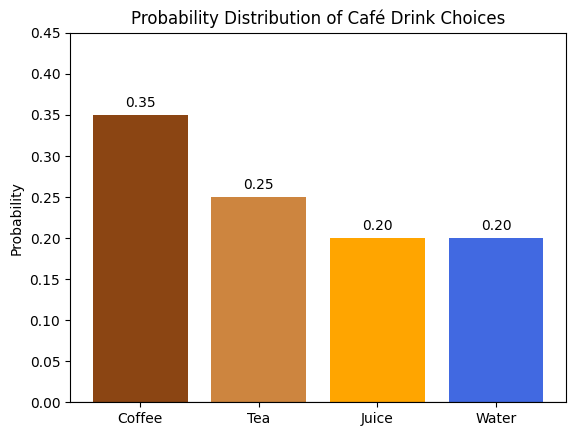

In [12]:
# defining sample space and probability distribution
outcomes = np.array(["Coffee", "Tea", "Juice", "Water"])
probabilities = np.array([0.35, 0.25, 0.20, 0.20])

# defining 2 disjoin events
event_A = np.isin(outcomes, ["Coffee", "Tea"])
event_B = np.isin(outcomes, ["Juice"])

# calculate probabilities
P_A = probabilities[event_A].sum()
P_B = probabilities[event_B].sum()
P_intersection = probabilities[event_A & event_B].sum()
P_union = probabilities[event_A | event_B].sum()

# chcek probability axioms
print("All probabilities are non-negative:",
      np.all(probabilities >= 0))

print("Total probability:", probabilities.sum())
print("Does the total equal 1?", np.isclose(probabilities.sum(), 1))

print("\nP(A) =", P_A)
print("P(B) =", P_B)
print("P(A ∩ B) =", P_intersection)
print("P(A ∪ B) =", P_union)
print("P(A) + P(B) =", P_A + P_B)

print("Disjoint axiom verified:",
      np.isclose(P_union, P_A + P_B))

# display probability distribution
colors = ["saddlebrown", "peru", "orange", "royalblue"]

plt.bar(outcomes, probabilities, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylim(0, 0.45)
plt.ylabel("Probability")
plt.title("Probability Distribution of Café Drink Choices")

for i, probability in enumerate(probabilities):
  plt.text(i, probability + 0.01, f"{probability:.2f}", ha="center")

plt.show()

The example above gives a "what if" on cafe records of drinks selected randomly by a chosen customer. The sample space is

$$
\Omega={\text{Coffee, Tea, Juice, Water}}.
$$

The assigned probabilites are $0.35$, $0.25$, $0.20$, and $0.20$, respectively. The probability axioms require:

1. Every probability is nonnegative: $P(E) \geq 0$.
2. The probabilities of all outcomes sum to one: $P(\Omega)=1$.
3. If events $A$ and $B$ are disjoint, then

$$
P(A \cup B)=P(A)+P(B).
$$

Let $A={\text{Coffee, Tea}}$ and $B={\text{Juice}}$.
These events are disjoint because a customer cannot select an outcome that belongs to both events.

# 2.2.2 Conditional Probability

Conditional probability measures the probability of an event occuring when another event is already known to have occurred. For events $A$ and $B$, it is calculated as

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)},
$$

where $P(B)>0$.

Using an example, suppose there is a class with 200 students. Let $A$ be the event that a student passes the exam and let $B$ be the event that the student attended a review session. Of the 80 students who attended the session, 72 passed. Of the 120 students who did not attend, 66 passed.

P(A) = P(pass) = 0.69
P(B) = P(attended) = 0.4
P(A ∩ B) = 0.36
P(A | B) = 0.9
Direct calculation: 72 / 80 = 0.9
Formula verified: True


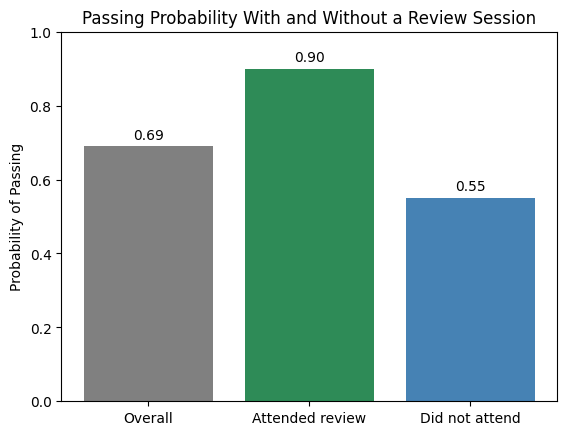

In [13]:
# student counts
total_students = 200

attended_and_passed = 72
attended_and_failed = 8

not_attended_and_passed = 66
not_attended_and_failed = 54

total_attended = attended_and_passed + attended_and_failed
total_not_attended = not_attended_and_passed + not_attended_and_failed
total_passed = attended_and_passed + not_attended_and_passed

# probabilites used in conditional formula
P_A = total_passed / total_students
P_B = total_attended / total_students
P_A_and_B = attended_and_passed / total_students

# P(A | B) = P(A and B) / P(B)
P_A_given_B = P_A_and_B / P_B

# probability of passing without attending
P_A_given_not_B = not_attended_and_passed / total_not_attended

print("P(A) = P(pass) =", round(P_A, 2))
print("P(B) = P(attended) =", round(P_B, 2))
print("P(A ∩ B) =", round(P_A_and_B, 2))
print("P(A | B) =", round(P_A_given_B, 2))

# verify result using student counts
direct_result = attended_and_passed / total_attended
print("Direct calculation: 72 / 80 =", round(direct_result, 2))
print("Formula verified:", np.isclose(P_A_given_B, direct_result))

# compare probabilities visually
labels = ["Overall", "Attended review", "Did not attend"]
values = [P_A, P_A_given_B, P_A_given_not_B]
colors = ["gray", "seagreen", "steelblue"]

plt.bar(labels, values, color=colors)
plt.ylim(0, 1)
plt.ylabel("Probability of Passing")
plt.title("Passing Probability With and Without a Review Session")

for i, value in enumerate(values):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

The output shows that the overall probability of passing is $0.69$, while the probability of passing given that a student attended the review session is $0.90$. The conditional probability is higher because the sample space is restricted to the 80 students who attended the session. The calcuation also verifies that $P(A\mid B)=P(A\cap B)/P(B)=0.36/0.40=0.90$.

# 2.2.3 Discrete Random Variables

A discrete random variable assigns a numerical value to each outcome of an experiment and has a countable set of possible values.

For example, a basketball player can take 3 independent shots and have a $0.70$ probability of making each shot. Let $X$ represent the number of successful shots. The possible values are

$$
X\in{0,1,2,3}.
$$

Since this is a binomial problem, the probability mass function is

$$
P(X=k)=\binom{3}{k}(0.70)^k(0.30)^{3-k}.
$$

P(X = 0) = 0.027
P(X = 1) = 0.189
P(X = 2) = 0.441
P(X = 3) = 0.343

Sum of probabilities = 1.0
Valid PMF: True
Expected value E[X] = 2.1
Variance Var(X) = 0.63
P(X >= 2) = 0.784

Expected value check: True
Variance check: True


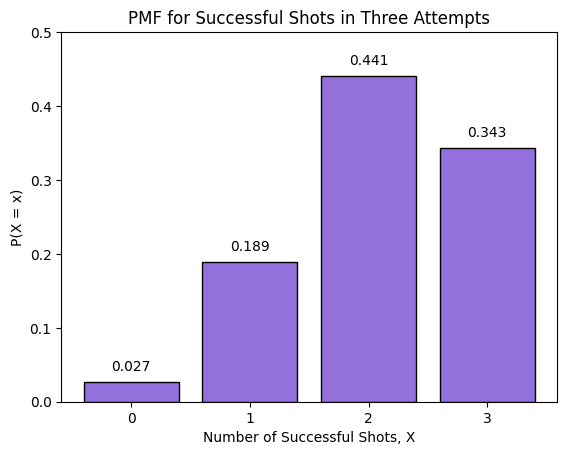

In [14]:
# define experiment
n = 3 # number of shots
p = 0.70 # probability of making one shot

# possible values of the discrete random variable X
x = np.arange(n + 1)

# calculate the probability mass function
pmf = np.array([
    comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
    for k in x
])

# calculate expected value and variance
expected_value = np.sum(x * pmf)
variance = np.sum((x - expected_value) ** 2 * pmf)

# display each possible value and its probability
for value, probability in zip(x, pmf):
  print(f"P(X = {value}) = {probability:.3f}")

print("\nSum of probabilities =", round(pmf.sum(), 3))
print("Valid PMF:", np.isclose(pmf.sum(), 1))
print("Expected value E[X] =", round(expected_value, 3))
print("Variance Var(X) =", round(variance, 3))
print("P(X >= 2) =", round(pmf[x >= 2].sum(), 3))

# compare with other possible binomial formulas
print("\nExpected value check:", np.isclose(expected_value, n * p))
print("Variance check:", np.isclose(variance, n * p * (1 - p)))

# plot probability mass function
plt.bar(x, pmf, color="mediumpurple", edgecolor="black")
plt.xticks(x)
plt.ylim(0, 0.50)
plt.xlabel("Number of Successful Shots, X")
plt.ylabel("P(X = x)")
plt.title("PMF for Successful Shots in Three Attempts")\

for value, probability in zip(x, pmf):
  plt.text(value, probability + 0.015,
           f"{probability:.3f}", ha="center")

plt.show()

The output verifies that the probabilities sum to $1$, so the distribution is a valid probability mass function. The most likely result is 2 successful shots, with a probability of $0.441$. The expected value is $E[X]=2.1$ which means that over many groups of three shots, the player would average about $2.1$ successful shots per group. The expected value does not need to be one of the possible outcomes.

# 2.2.4 Continuous Random Variables

A continous random variable can take any value within an interval. Probabilites are found by calculating the area under its probability density function rather than assigning a probability to each individual value.

Using an example, there is a delivery time $X$ that is equally distributed between 20 and 50 minutes. Its probability density function is

$$
f(x)=
\left\{
\begin{array}{ll}
\frac{1}{30}, & 20\leq x\leq 50,\\
0, & \text{otherwise}
\end{array}
\right\}
$$

Density = 0.0333
Total area under the PDF = 1.0
Valid PDF: True
P(25 <= X <= 35) = 0.3333
P(X = 30) = 0 for a continuous random variable


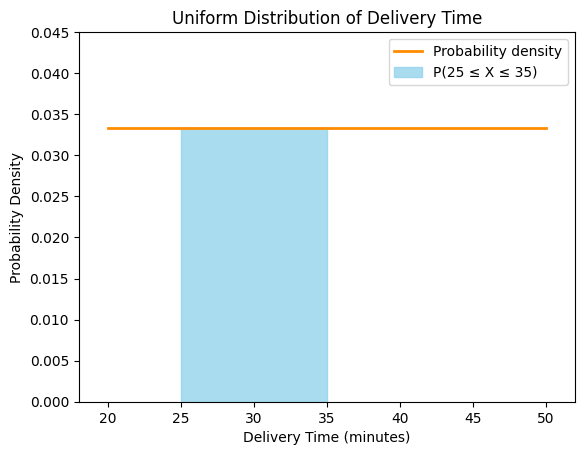

In [15]:
# define uniform distribution
a = 20
b = 50
density = 1 / (b - a)

# create values for plotting
x = np.linspace(a, b, 1000)
pdf = np.full_like(x, density)

# probability interval
lower = 25
upper = 35

# area = width x height
total_area = (b - a) * density
interval_probability = (upper - lower) * density

print("Density =", round(density, 4))
print("Total area under the PDF =", round(total_area, 4))
print("Valid PDF:", np.isclose(total_area, 1))
print("P(25 <= X <= 35) =", round(interval_probability, 4))
print("P(X = 30) = 0 for a continuous random variable")

# select the interval to shade
interval = (x >= lower) & (x <= upper)

# plot probability density function
plt.plot(x, pdf, color="darkorange", linewidth=2,
         label="Probability density")

plt.fill_between(
    x[interval],
    pdf[interval],
    color="skyblue",
    alpha=0.7,
    label="P(25 ≤ X ≤ 35)"
)

plt.xlim(18, 52)
plt.ylim(0, 0.045)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.title("Uniform Distribution of Delivery Time")
plt.legend()
plt.show()

The output shows that the total area under the probability density function is $1$, confirming that it is a valid probability distribution. The shaded area between 25 and 35 minutes is approximately $0.3333$, meaning there is about a $33.33%$ chance that the delivery time falls within this interval. Since $X$ is continous, the probability of the delivery taking exactly 30 minutes is $0$.

# Reflection


*   Probability axioms: Based on the cafe drink choices, created a probability distribution and verified that every probability was nonnegative and that the total was 1. As well checked the addition rule for 2 disjoint events.
*   Conditional probability: Used student exam results to calculate the probability of passing given that a student attended a review session. Verified conditional probability formula and compared it with the overall passing probability.
*   Discrete random variables: Displayed the number of successful basketball shots in 3 attempts, calculated the probability mass function, expected value, and variance, and verified that the probabilites summed to 1.
*   Continuous random variables: Modeled delivery time with a uniform distribution between 20 and 50 minutes. Verified that the toal area under the probability density function was 1, and found the probability of a delivery taking between 25 and 35 minutes.

